In [1]:
import os
from re import search
import pandas as pd
import numpy as np

import scanpy as sc

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn import metrics
from sklearn.metrics import confusion_matrix

from scipy.special import softmax
from scipy.stats import zscore
from scipy import sparse

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from multiprocessing import Pool

from anndata import AnnData

from numba import njit, prange

from tqdm import tqdm

import pickle
import gc

import warnings

matplotlib.rcParams.update({'font.size': 12})
%config InlineBackend.figure_format = 'retina'
%matplotlib inline
warnings.filterwarnings('ignore')

## Figure 1e

In [2]:
prediction = pd.read_csv('/media/gary/extdrv/Jesse/CrossSpeciesMappings/all_species_matthews_withshuffle_20250812.csv',index_col=0 )

In [3]:
prediction = prediction[prediction['Features'].isin(['Promoters', 'NonPromoters','Shuffle'])]

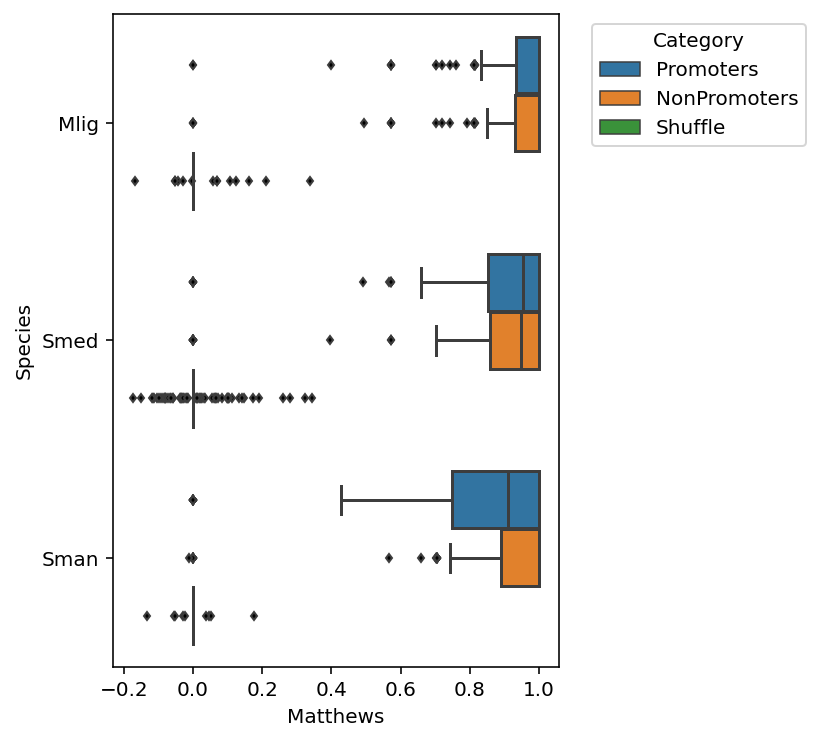

In [4]:
plt.figure(figsize=(4, 6))  # width=10, height=6 inches

sns.boxplot( data=prediction, y='Species', hue='Features', x='Matthews',flierprops=dict( markersize=3, markerfacecolor='black', alpha=1) )
plt.legend(
    title="Category",
    bbox_to_anchor=(1.05, 1),  # x, y position relative to axes
    loc='upper left'
)
#plt.savefig("Peak_prediction.svg",format="svg")
plt.show()

# Figure 1d 

In [ ]:
dfM = pd.read_csv( 'Metadata/Mlig.final_cluster_annots.csv', index_col=0 )
dfM = dfM.loc[dfM.GroupFigure!='???-1',:]
dfM = pd.crosstab( dfM.GroupFigure, dfM.Sample )
dfM = dfM.div( dfM.sum(1), axis=0 )
plotOrder = ['Cathepsin', 'Intestine-1', 'Intestine-2', 'GSC', 'Female Germline', 'Male Germline', 'Neoblast', 'Neural Progenitors', 'Neural-1', 'Neural-2', 'Neural-3',
             'Neural-4', 'Neural-5', 'Muscle', 'Epidermal Progenitors', 'Epidermal-1', 'Epidermal-2', 'Parenchymal-1', 'Parenchymal-2', 'Parenchymal-3', 'Parenchymal-4',
             'Parenchymal-5', 'Protonephridia', 'Anchor Cells']

dfM = dfM.reindex(plotOrder).reset_index()
ax = dfM.plot.barh(x='GroupFigure', stacked=True, figsize=(6,12)).legend(bbox_to_anchor=(1.0,1.0))
plt.gca().invert_yaxis()
plt.savefig('Plots/Fig1/Panel1c_Mlig.svg.svg',format = 'svg')

In [ ]:
dfP = pd.read_csv( 'Metadata/Smed.final_cluster_annots.csv', index_col=0 )
dfP = pd.crosstab( dfP.GroupFigure, dfP.Sample )
dfP = dfP.div( dfM.sum(1), axis=0 )
plotOrder = ['Cathepsin', 'Intestine-1', 'Intestine-2', 'Ophis', 'GSC', 'GSC progeny/diff germline', 'Neoblast-1', 'Neoblast-2', 'Neural Progenitors', 
             'Neural-1', 'Neural-2', 'Neural-3', 'Muscle-1', 'Muscle-2', 'Muscle-3', 'Epidermal-1', 'Epidermal-2', 'Pharynx', 'Parenchymal', 
             'Protonephridia']

dfP = dfP.reindex(plotOrder).reset_index()
ax = dfP.plot.barh(x='GroupFigure', stacked=True, figsize=(6,12)).legend(bbox_to_anchor=(1.0,1.0))
plt.gca().invert_yaxis()
plt.savefig('Plots/Fig1/Panel1c_Smed.svg',format = 'svg')

In [ ]:
dfS = pd.read_csv( 'Metadata/Sman.final_cluster_annots.csv', index_col=0 )
dfS = pd.crosstab( dfS.GroupFigure, dfM.Sample )
dfS = dfS.div( dfS.sum(1), axis=0 )
plotOrder = ['Cathepsin', 'Intestine', 'S1', 'GSC', 'Neoblast', 'Neural Progenitors', 'Neural-1', 'Neural-2', 'Neural-3', 'Neural-4', 
             'Neural-5', 'Neural-6', 'Muscle Progenitors', 'Muscle-1', 'Muscle-2', 'Muscle-3', 'Tegument Progenitors', 'Tegument-1', 
             'Tegument-2', 'Vitellocytes', 'Esophageal Gland', 'Protonephridia']

dfS = dfS.reindex(plotOrder).reset_index()
ax = dfS.plot.barh(x='GroupFigure', stacked=True, figsize=(6,12)).legend(bbox_to_anchor=(1.0,1.0))
plt.gca().invert_yaxis()
plt.savefig('Plots/Fig/Panel1c_Sman.svg',format = 'svg')